# PMTiles Web Map Visualization

This notebook demonstrates interactive web map visualization of HMS model data
exported to cloud-native formats using [hms2cng](https://github.com/gpt-cmdr/hms2cng).

| Visualization | Library | Use Case |
|---------------|---------|----------|
| Interactive map | leafmap | Explore geometry + results |
| Styled markers | folium | Peak flow visualization |
| Multi-layer | leafmap | Subbasins + reaches overlay |

**Prerequisites**:
- `pip install "hms2cng[all]" leafmap folium`
- Run notebook 19 first, or this notebook will generate its own data

**Estimated Time**: 2-5 minutes

In [1]:
# pip install hms-commander "hms2cng[all]" leafmap folium

**For Development**: If working on hms-commander source code, use the `hmscmdr_local` conda environment (editable install) instead of pip install.

In [2]:
from pathlib import Path
from hms_commander import HmsExamples, init_hms_project, HmsBasin
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

print("hms-commander loaded")

try:
    from hms2cng import get_basin_layer_gdf, merge_all_layers, export_basin_geometry
    print("hms2cng loaded")
    HMS2CNG_AVAILABLE = True
except ImportError:
    print("hms2cng not installed. Install with: pip install 'hms2cng[all]'")
    HMS2CNG_AVAILABLE = False

try:
    import leafmap
    LEAFMAP_AVAILABLE = True
    print("leafmap loaded")
except ImportError:
    LEAFMAP_AVAILABLE = False
    print("leafmap not installed. Install with: pip install leafmap")

try:
    import folium
    from folium.plugins import MarkerCluster
    FOLIUM_AVAILABLE = True
    print("folium loaded")
except ImportError:
    FOLIUM_AVAILABLE = False
    print("folium not installed. Install with: pip install folium")

hms-commander loaded


hms2cng loaded


leafmap loaded
folium loaded


## 1. Prepare HMS Model Data

Extract an HMS example project and export geometry to GeoDataFrames.

**Note on coordinates**: HMS example projects store element positions as
schematic canvas coordinates (not real-world lat/lon). The maps below use
these canvas coordinates directly. For real-world positioning, use an HMS
project that has been georeferenced (has a `.sqlite` with terrain data or
a known CRS).

In [3]:
if HMS2CNG_AVAILABLE:
    # Extract example project
    project_path = HmsExamples.extract_project(
        "tifton",
        output_path=Path.cwd() / "hms_example_projects" / "tifton_web_map"
    )
    hms = init_hms_project(project_path)
    basin_file = list(project_path.glob("*.basin"))[0]

    # Export geometry layers (some may not exist in all projects)
    gdf_subbasins = get_basin_layer_gdf(basin_file, layer="subbasins")

    try:
        gdf_reaches = get_basin_layer_gdf(basin_file, layer="reaches")
    except (ValueError, AttributeError):
        gdf_reaches = None

    try:
        gdf_junctions = get_basin_layer_gdf(basin_file, layer="junctions")
    except (ValueError, AttributeError):
        gdf_junctions = None

    # Check if CRS is available for web mapping
    HAS_CRS = gdf_subbasins.crs is not None

    print(f"Project: {hms.project_name}")
    print(f"Subbasins: {len(gdf_subbasins)}")
    print(f"Reaches: {len(gdf_reaches) if gdf_reaches is not None else 0}")
    print(f"Junctions: {len(gdf_junctions) if gdf_junctions is not None else 0}")
    print(f"CRS: {gdf_subbasins.crs or 'None (schematic coordinates)'}")
    if not HAS_CRS:
        print("\nNote: This project uses schematic canvas coordinates.")
        print("Web basemap overlays require a known CRS.")
        print("Matplotlib plots will be used instead.")
else:
    print("hms2cng not available -- install with: pip install 'hms2cng[all]'")

2026-04-19 17:38:54 - hms_commander.HmsExamples - INFO - Found HMS 4.10 at C:\Program Files\HEC\HEC-HMS\4.10


2026-04-19 17:38:54 - hms_commander.HmsExamples - INFO - Found HMS 4.11 at C:\Program Files\HEC\HEC-HMS\4.11


2026-04-19 17:38:54 - hms_commander.HmsExamples - INFO - Found HMS 4.12 at C:\Program Files\HEC\HEC-HMS\4.12


2026-04-19 17:38:54 - hms_commander.HmsExamples - INFO - Found HMS 4.13 at C:\Program Files\HEC\HEC-HMS\4.13


2026-04-19 17:38:54 - hms_commander.HmsExamples - INFO - Found HMS 4.4.1 at C:\Program Files\HEC\HEC-HMS\4.4.1


...

2026-04-19 17:38:55 - hms_commander.HmsPrj - INFO -   Simulation runs: 1


2026-04-19 17:38:55 - hms_commander.HmsPrj - INFO -   Gages: 2


2026-04-19 17:38:55 - hms_commander.HmsPrj - INFO -   Paired data tables: 0


2026-04-19 17:38:55 - hms_commander.HmsPrj - INFO -   CRS: Not detected (specify crs_epsg manually)


Project: tifton
Subbasins: 1
Reaches: 0
Junctions: 1
CRS: None (schematic coordinates)

Note: This project uses schematic canvas coordinates.
Web basemap overlays require a known CRS.
Matplotlib plots will be used instead.


## 2. Basic Map with Leafmap

Display subbasin locations on an interactive map with OpenStreetMap base layer.

**Note**: Web basemap overlays require a known CRS so coordinates can be
reprojected to WGS84 (lat/lon). If the project uses schematic coordinates,
the notebook falls back to matplotlib plots.

In [4]:
if HMS2CNG_AVAILABLE and LEAFMAP_AVAILABLE and HAS_CRS:
    import geopandas as gpd

    gdf = gdf_subbasins.to_crs(epsg=4326)

    bounds = gdf.total_bounds
    center_lat = (bounds[1] + bounds[3]) / 2
    center_lon = (bounds[0] + bounds[2]) / 2

    m = leafmap.Map(center=(center_lat, center_lon), zoom=11)
    m.add_gdf(
        gdf,
        layer_name="Subbasins",
        style={"color": "blue", "fillColor": "steelblue", "weight": 2, "fillOpacity": 0.5},
    )
    display(m)
elif HMS2CNG_AVAILABLE and not HAS_CRS:
    print("Skipping web map: project uses schematic coordinates (no CRS).")
    print("See Section 6 for matplotlib fallback plots.")
else:
    print("leafmap or hms2cng not available")

Skipping web map: project uses schematic coordinates (no CRS).
See Section 6 for matplotlib fallback plots.


## 3. Multi-Layer Map

Overlay subbasins, reaches, and junctions on the same map. Each layer
can be toggled independently using the layer control.

In [5]:
if HMS2CNG_AVAILABLE and LEAFMAP_AVAILABLE and HAS_CRS:
    import geopandas as gpd

    m = leafmap.Map(center=(center_lat, center_lon), zoom=11)

    if gdf_reaches is not None:
        gdf_r = gdf_reaches.to_crs(epsg=4326)
        m.add_gdf(gdf_r, layer_name="Reaches", style={"color": "dodgerblue", "weight": 3})

    gdf = gdf_subbasins.to_crs(epsg=4326)
    m.add_gdf(gdf, layer_name="Subbasins",
        style={"color": "green", "fillColor": "limegreen", "weight": 2, "fillOpacity": 0.7})

    if gdf_junctions is not None:
        gdf_j = gdf_junctions.to_crs(epsg=4326)
        m.add_gdf(gdf_j, layer_name="Junctions",
            style={"color": "red", "fillColor": "red", "weight": 2, "fillOpacity": 0.8})

    display(m)
elif HMS2CNG_AVAILABLE and not HAS_CRS:
    print("Skipping multi-layer web map: no CRS available.")
else:
    print("leafmap or hms2cng not available")

Skipping multi-layer web map: no CRS available.


## 4. Folium Map with Popups

Create a folium map with detailed popups showing subbasin properties
(name, area, loss method, transform method). Click any marker to inspect.

In [6]:
if HMS2CNG_AVAILABLE and FOLIUM_AVAILABLE and HAS_CRS:
    import geopandas as gpd

    gdf_plot = gdf_subbasins.to_crs(epsg=4326)

    bounds = gdf_plot.total_bounds
    center_lat = (bounds[1] + bounds[3]) / 2
    center_lon = (bounds[0] + bounds[2]) / 2

    m_folium = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=11,
        tiles="OpenStreetMap"
    )

    for _, row in gdf_plot.iterrows():
        popup_html = f"""
        <b>{row.get('name', 'N/A')}</b><br>
        Area: {row.get('area', 'N/A')}<br>
        Loss: {row.get('loss_method', 'N/A')}<br>
        Transform: {row.get('transform_method', 'N/A')}<br>
        Downstream: {row.get('downstream', 'N/A')}
        """
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=8,
            popup=folium.Popup(popup_html, max_width=250),
            color="steelblue",
            fill=True,
            fill_color="steelblue",
            fill_opacity=0.7,
        ).add_to(m_folium)

    if gdf_reaches is not None:
        gdf_r_plot = gdf_reaches.to_crs(epsg=4326)
        for _, row in gdf_r_plot.iterrows():
            if row.geometry and row.geometry.geom_type == "LineString":
                coords = [(y, x) for x, y in row.geometry.coords]
                folium.PolyLine(
                    coords, weight=3, color="dodgerblue",
                    popup=row.get("name", ""),
                ).add_to(m_folium)

    display(m_folium)
elif HMS2CNG_AVAILABLE and not HAS_CRS:
    print("Skipping folium map: no CRS for WGS84 reprojection.")
else:
    print("folium or hms2cng not available")

Skipping folium map: no CRS for WGS84 reprojection.


## 5. Subbasin Properties Table

Display a summary table of all subbasin properties alongside the map.

In [7]:
if HMS2CNG_AVAILABLE:
    import pandas as pd

    # Select relevant columns (exclude geometry)
    display_cols = [c for c in gdf_subbasins.columns if c != "geometry"]

    summary = gdf_subbasins[display_cols].copy()
    print(f"Subbasin Properties ({len(summary)} elements):")
    display(summary)
else:
    print("hms2cng not available")

Subbasin Properties (1 elements):


,name,area,downstream,loss_method,transform_method,baseflow_method,percent_impervious,canvas_x,canvas_y
0,74006,19.27,Station I,None,Clark,Linear Reservoir,0.0,241449.675574,3.512248e+06


## 6. Static Plot (Matplotlib Fallback)

For environments without leafmap/folium, use matplotlib for basic visualization.
This always works since geopandas includes matplotlib plotting support.

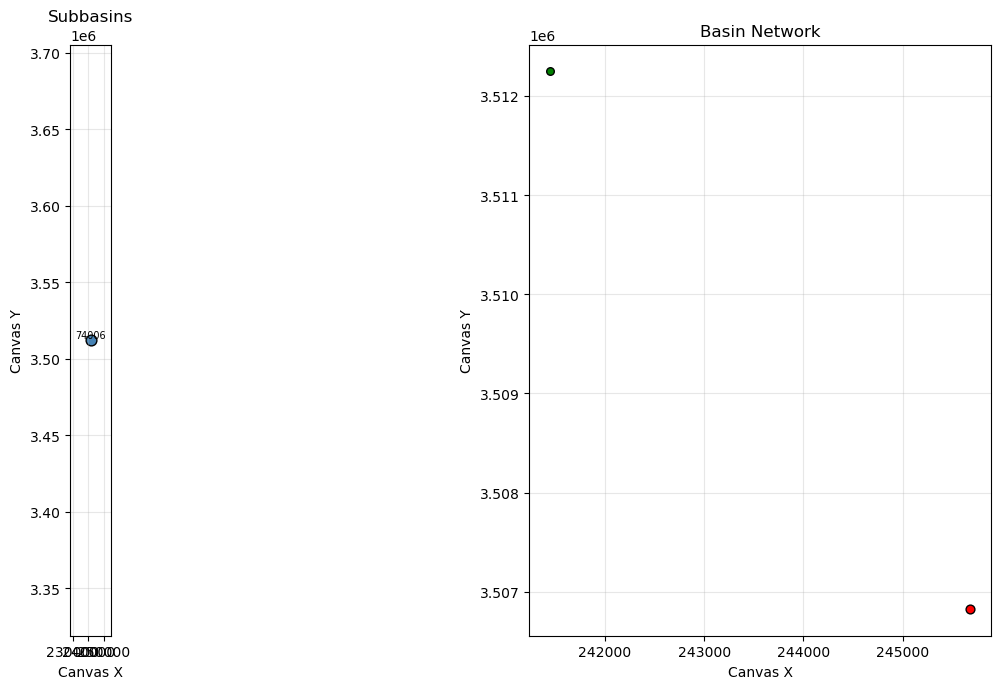

In [8]:
if HMS2CNG_AVAILABLE:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Plot 1: Subbasins with labels
    ax1 = axes[0]
    gdf_subbasins.plot(ax=ax1, color="steelblue", edgecolor="black", markersize=60)
    for _, row in gdf_subbasins.iterrows():
        ax1.annotate(
            row.get("name", ""),
            xy=(row.geometry.x, row.geometry.y),
            fontsize=7, ha="center", va="bottom",
        )
    ax1.set_title("Subbasins")
    ax1.set_xlabel("Canvas X")
    ax1.set_ylabel("Canvas Y")
    ax1.grid(True, alpha=0.3)

    # Plot 2: Network (reaches + junctions + subbasins)
    ax2 = axes[1]
    if gdf_reaches is not None:
        gdf_reaches.plot(ax=ax2, color="dodgerblue", linewidth=2)
    if gdf_junctions is not None:
        gdf_junctions.plot(ax=ax2, color="red", markersize=40, edgecolor="black", zorder=5)
    gdf_subbasins.plot(ax=ax2, color="green", markersize=30, edgecolor="black", zorder=4)
    ax2.set_title("Basin Network")
    ax2.set_xlabel("Canvas X")
    ax2.set_ylabel("Canvas Y")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("hms2cng not available")

## Summary

This notebook demonstrated web map visualization of HMS model data:

| Technique | Library | Best For |
|-----------|---------|----------|
| Interactive GDF overlay | leafmap | Quick exploration |
| Popups with properties | folium | Detailed inspection |
| Multi-layer overlay | leafmap | Network visualization |
| Static plots | matplotlib | Reports and presentations |

## Serving PMTiles

To serve PMTiles files for web applications:

1. **Local**: `python -m http.server` in the directory with .pmtiles files
2. **Cloud**: Upload to any static file host (S3, GCS, Azure Blob, GitHub Pages)
3. **Viewer**: Use [PMTiles Viewer](https://protomaps.github.io/PMTiles/) to inspect

PMTiles files use HTTP range requests, so no tile server is needed.

## Next Steps

- **19_cloud_native_export.ipynb**: Generate GeoParquet and PMTiles
- **06_results_dss.ipynb**: DSS-based results extraction
- **hms2cng docs**: https://hms2cng.readthedocs.io/